<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/Day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Regression

# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)



Generated dataset file.
shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


baseline RMSE: 1032.5 kWh | R2: 0.727


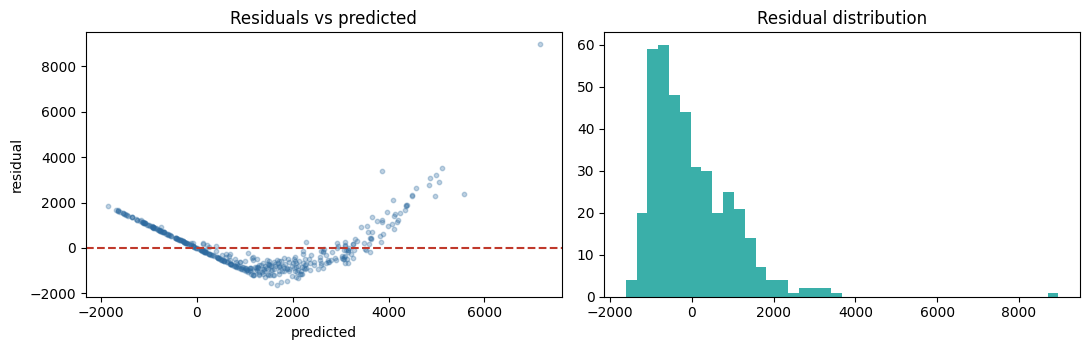

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


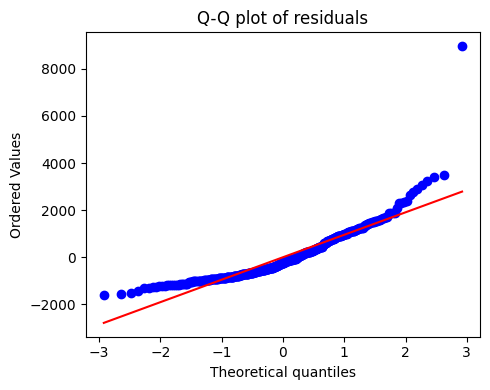

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')


# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')



In [ ]:
from scipy.stats import skew

# 1. describe the residual pattern:
# Residual plot shows a curved pattern and a slight fan shape.
# This indicates non-linearity and heteroscedasticity
# (variance increases as predicted values increase).

# 2. skew of the target
target_skew = skew(y)
print("Target Skewness =", round(target_skew, 3))

if target_skew > 1:
    print("The target is right-skewed (positively skewed).")
else:
    print("The target is not strongly right-skewed.")

Target Skewness = 2.211
The target is right-skewed (positively skewed).


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


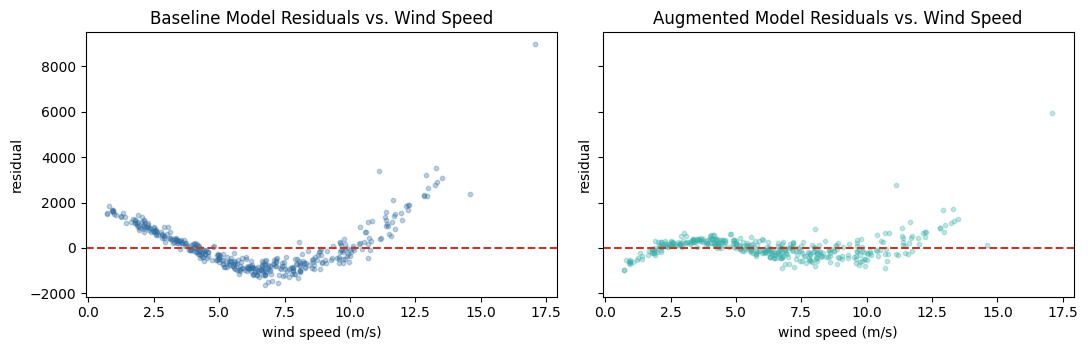

The cubic relationship between wind speed and energy is largely captured by the augmented model, resulting in a much flatter residual plot.


In [ ]:
wind_test = X_test[:, wi]
resid_base = y_test - pred
resid_aug = y_test - pred_aug

# 1-2. residuals vs wind for baseline and augmented
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True, sharey=True)
ax[0].scatter(wind_test, resid_base, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('wind speed (m/s)'); ax[0].set_ylabel('residual')
ax[0].set_title('Baseline Model Residuals vs. Wind Speed')
ax[1].scatter(wind_test, resid_aug, s=10, alpha=0.3, color='#3AAFA9')
ax[1].axhline(0, color='#C0392B', ls='--'); ax[1].set_xlabel('wind speed (m/s)'); ax[1].set_ylabel('residual')
ax[1].set_title('Augmented Model Residuals vs. Wind Speed')
plt.tight_layout(); plt.show()

# 3. is the curve gone? ...   (comment)
print('The cubic relationship between wind speed and energy is largely captured by the augmented model, resulting in a much flatter residual plot.')

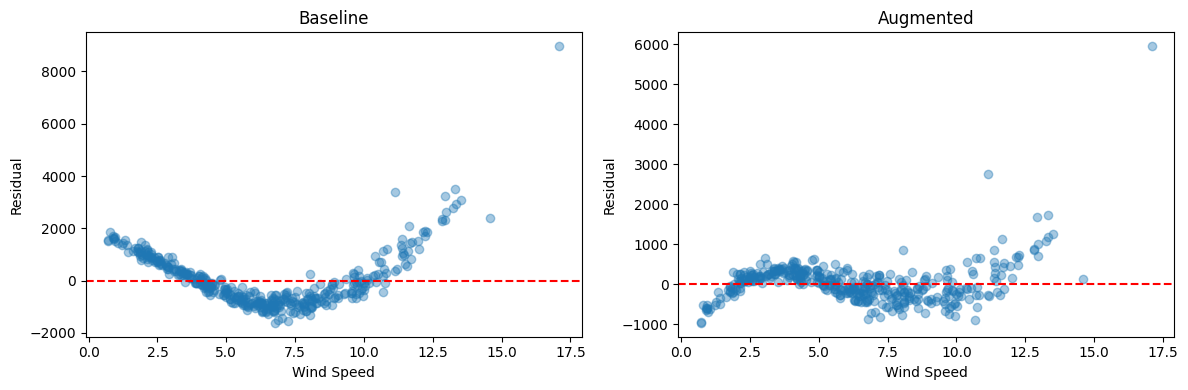

In [ ]:
models = [
    ("Baseline", pred),
    ("Augmented", pred_aug)
]

fig, ax = plt.subplots(1, 2, figsize=(12,4))

for i, (name, prediction) in enumerate(models):
    residuals = y_test - prediction

    ax[i].scatter(wind_test, residuals, alpha=0.4)
    ax[i].axhline(0, color='red', linestyle='--')
    ax[i].set_title(name)
    ax[i].set_xlabel("Wind Speed")
    ax[i].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE THE THREE (scaled, degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In [ ]:
# 1. l1_ratio sweep (reuse score_model with ElasticNet)
for r in [0.1, 0.3, 0.5, 0.7, 0.9]:
    mdl = ElasticNet(alpha=1.0, l1_ratio=r, max_iter=10000)
    print(f'l1_ratio={r:.1f} test R2: {score_model(mdl):.3f}')


# 2. best mix + meaning of the extremes: ...   (comment)

l1_ratio=0.1 test R2: 0.833
l1_ratio=0.3 test R2: 0.848
l1_ratio=0.5 test R2: 0.863
l1_ratio=0.7 test R2: 0.878
l1_ratio=0.9 test R2: 0.898


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


In [ ]:
y_pred = ols.predict(X_test)
residuals = y_test - y_pred
sigma = residuals.std()
outliers = np.abs(residuals) > 3*sigma

print("Outliers =", outliers.sum())

Outliers = 4


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


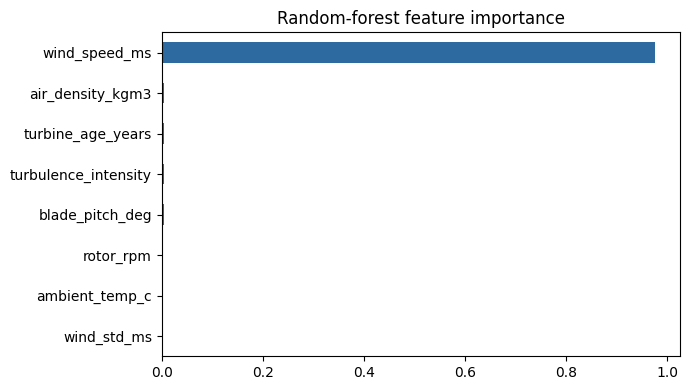

In [ ]:
# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=0)

# Define the parameter grid for n_estimators
param_grid = {'max_depth': [6, 10, None],'n_estimators': [200, 400]}

# 2. Grid Search
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# 3. Best parameters
print("Best Parameters:", grid.best_params_)

# 4. Evaluate on test set
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

test_r2 = r2_score(y_test, y_pred)

print("Tuned RF Test R²:", round(test_r2, 3))

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Tuned RF Test R²: 0.933


In [ ]:
#classification

# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)



Generated dataset file.
shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


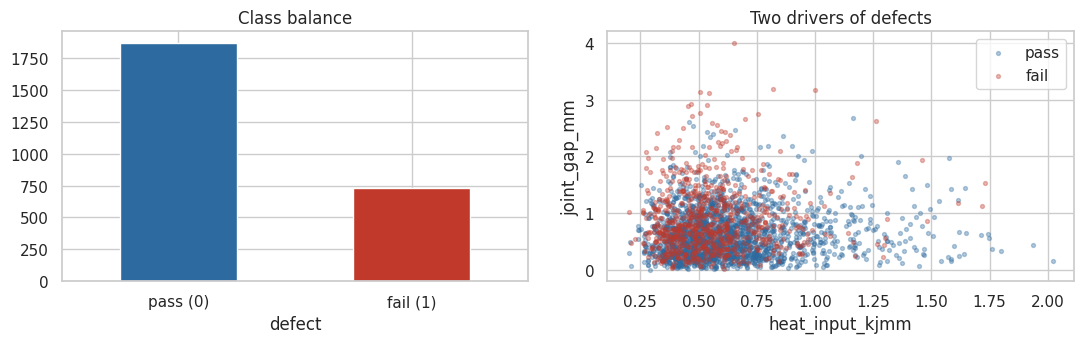

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [ ]:


# -----------------------------------------------------------
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')



In [ ]:
# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


In [ ]:
# 1. model accuracy
model_acc = clf.score(X_test, y_test)
print("Model Accuracy:", round(model_acc, 3))

# 2. always-pass accuracy
always_pass_acc = 1 - y_test.mean()
print("Always Predict Pass Accuracy:", round(always_pass_acc, 3))

# 3. why accuracy misleads here:
# If defects are rare, predicting every weld as "pass" can achieve
# high accuracy while completely missing defective welds.
# Therefore, accuracy alone does not tell us whether the model is
# actually detecting defects. Metrics like Recall, Precision,
# ROC-AUC, and Confusion Matrix are more informative.

Model Accuracy: 0.728
Always Predict Pass Accuracy: 0.718


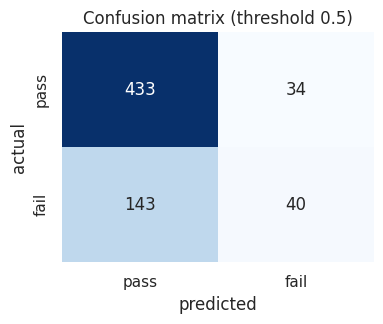

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [ ]:


# -----------------------------------------------------------
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))



In [ ]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.93      0.83       467
           1       0.54      0.22      0.31       183

    accuracy                           0.73       650
   macro avg       0.65      0.57      0.57       650
weighted avg       0.69      0.73      0.68       650



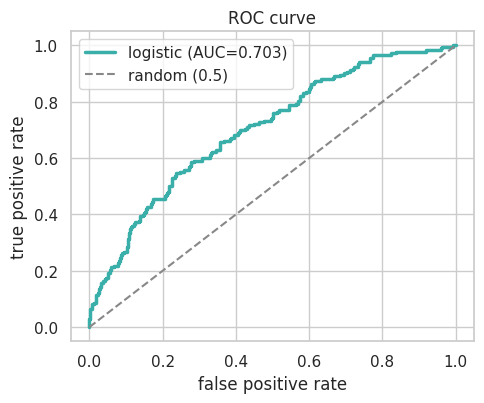

ROC-AUC: 0.703  (1.0 = perfect, 0.5 = random)


In [ ]:


# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')



Logistic AUC: 0.703
RF AUC: 0.663


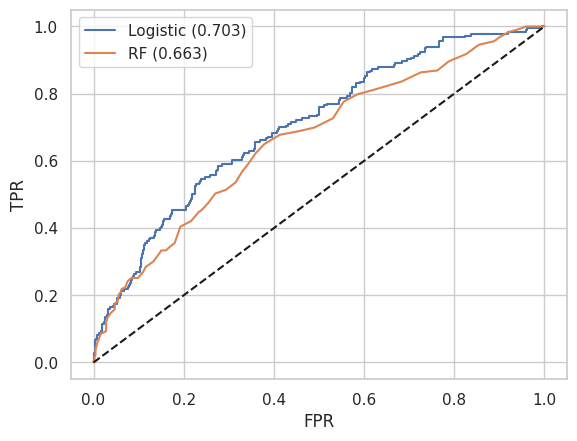

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Random Forest
rf = Pipeline([
    ('prep', pre),
    ('rf', RandomForestClassifier(random_state=42))
]).fit(X_train, y_train)

# Probabilities and AUC
rf_proba = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_proba)
log_auc = roc_auc_score(y_test, proba)

print("Logistic AUC:", round(log_auc,3))
print("RF AUC:", round(rf_auc,3))

# ROC Curves
fpr1, tpr1, _ = roc_curve(y_test, proba)
fpr2, tpr2, _ = roc_curve(y_test, rf_proba)

plt.plot(fpr1, tpr1, label=f'Logistic ({log_auc:.3f})')
plt.plot(fpr2, tpr2, label=f'RF ({rf_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

# Which ranks better?
# The model with the higher ROC-AUC ranks defects better.

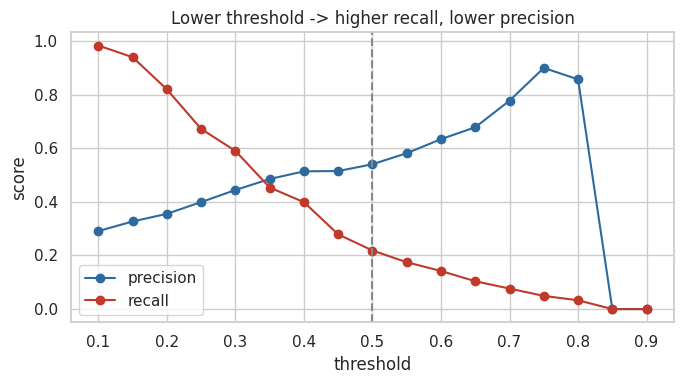

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve

# precision, recall, thresholds
prec, rec, thr = precision_recall_curve(y_test, proba)

# highest threshold with recall >= 0.85
i = np.where(rec[:-1] >= 0.85)[0][-1]

print("Threshold:", round(thr[i], 3))
print("Recall:", round(rec[i], 3))
print("Precision:", round(prec[i], 3))

# Trade-off:
# Lowering the threshold increases recall (catches more defects)
# but decreases precision (more false alarms/re-inspections).
# We accept more re-inspections to avoid missing dangerous defects.

Threshold: 0.194
Recall: 0.852
Precision: 0.357


In [ ]:


# -----------------------------------------------------------
# 🔹 6A. exp(coefficient) = ODDS-RATIO PER +1 SD
# -----------------------------------------------------------
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())



Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


# **CAPSTONE -  4**

In [ ]:


# === SETUP: load the three provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


def build_telco(cust_csv='telco_customers.csv',
                usage_xlsx='telco_usage.xlsx',
                tickets_csv='telco_support_tickets.csv',
                seed=7, verbose=False):
    """Generate a realistic telecom churn case-study dataset across THREE sources.

    Files (all join on customer_id):
      - telco_customers.csv        : one row per customer (accounts + contract + target)
      - telco_usage.xlsx           : monthly usage (CDR summary), 3 months per customer
      - telco_support_tickets.csv  : one row per support ticket raised

    Built-in realism for the Day 1-4 capstone:
      - 'total_charges' stored as TEXT with blanks for brand-new customers (classic Telco quirk)
      - missing values, a few duplicate rows, messy contract casing
      - churn has real signal: contract type, tenure, charges, dropped calls, tickets, payment type
      - target churn rate ~25% (imbalanced)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    snapshot = pd.Timestamp('2024-06-30')

    cid = np.array([f'TEL{i+1:05d}' for i in range(N)])
    tenure = rng.integers(0, 73, N)                       # months with the operator
    signup = snapshot - pd.to_timedelta((tenure * 30).astype(int), unit='D')

    gender = rng.choice(['Male', 'Female'], N, p=[.5, .5])
    senior = rng.choice([0, 1], N, p=[.84, .16])
    partner = rng.choice(['Yes', 'No'], N, p=[.48, .52])
    dependents = rng.choice(['Yes', 'No'], N, p=[.30, .70])
    contract = rng.choice(['Month-to-month', 'One year', 'Two year'], N, p=[.55, .21, .24])
    payment = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
                         N, p=[.34, .23, .22, .21])
    paperless = rng.choice(['Yes', 'No'], N, p=[.59, .41])
    internet = rng.choice(['DSL', 'Fiber optic', 'No'], N, p=[.34, .44, .22])

    def service(prob_yes):
        out = np.where(internet == 'No', 'No internet service',
                       np.where(rng.random(N) < prob_yes, 'Yes', 'No'))
        return out
    online_security = service(0.35)
    tech_support = service(0.37)

    base = np.where(internet == 'Fiber optic', 70.0, np.where(internet == 'DSL', 45.0, 20.0))
    monthly = base + (online_security == 'Yes') * 5 + (tech_support == 'Yes') * 5 + rng.normal(0, 8, N)
    monthly = np.clip(monthly, 18, 120).round(2)
    total_num = (monthly * tenure).round(2)

    state = rng.choice(['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu',
                        'Telangana', 'Gujarat', 'West Bengal'],
                       N, p=[.20, .16, .14, .14, .12, .12, .12])

    # per-customer network/usage propensities
    avg_minutes = np.clip(rng.normal(620, 220, N), 20, None).round(0)
    avg_data_gb = np.clip(rng.gamma(2.0, 3.5, N), 0.1, None).round(2)
    avg_sms = rng.poisson(40, N)
    dropped_rate = np.clip(rng.gamma(1.5, 1.2, N), 0, None)          # avg dropped calls/month
    n_tickets = rng.poisson(0.7 + 0.15 * dropped_rate)              # complaints track dropped calls

    # ---- churn logit (real, interpretable signal) ----
    z = (-1.5
         + 1.30 * (contract == 'Month-to-month')
         - 0.95 * (contract == 'Two year')
         + 0.016 * (monthly - 60)
         - 0.030 * tenure
         + 0.55 * (payment == 'Electronic check')
         + 0.40 * (internet == 'Fiber optic')
         - 0.45 * (tech_support == 'Yes')
         - 0.30 * (online_security == 'Yes')
         + 0.18 * dropped_rate
         + 0.22 * n_tickets)
    p = 1 / (1 + np.exp(-z))
    churn = np.where(rng.random(N) < p, 'Yes', 'No')

    # ---- total_charges as TEXT, blank for tenure==0 (classic quirk) ----
    total_charges = np.where(tenure == 0, '', total_num.astype(str))

    df = pd.DataFrame({
        'customer_id': cid, 'signup_date': pd.to_datetime(signup).date.astype('str'),
        'gender': gender, 'senior_citizen': senior, 'partner': partner,
        'dependents': dependents, 'state': state, 'tenure_months': tenure,
        'contract': contract, 'payment_method': payment, 'paperless_billing': paperless,
        'internet_service': internet, 'online_security': online_security,
        'tech_support': tech_support, 'monthly_charges': monthly,
        'total_charges': total_charges, 'churn': churn,
    })

    # ---- inject messiness ----
    mc = rng.choice(N, int(0.04 * N), replace=False)          # messy contract casing
    df.loc[mc, 'contract'] = df.loc[mc, 'contract'].str.lower() + ' '
    for col, frac in [('gender', 0.03), ('partner', 0.02), ('online_security', 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    dups = df.sample(8, random_state=1)                        # a few duplicate rows
    df = pd.concat([df, dups], ignore_index=True)

    # ---- usage (3 monthly rows per customer) ----
    months = ['2024-04', '2024-05', '2024-06']
    rows = []
    for i in range(N):
        for m in months:
            rows.append((cid[i], m,
                         max(0, round(float(rng.normal(avg_minutes[i], avg_minutes[i] * 0.15)))),
                         max(0.0, round(float(rng.normal(avg_data_gb[i], avg_data_gb[i] * 0.2)), 2)),
                         max(0, int(rng.normal(avg_sms[i], 8))),
                         max(0, int(rng.normal(dropped_rate[i], 1)))))
    usage = pd.DataFrame(rows, columns=['customer_id', 'month', 'call_minutes',
                                        'data_gb', 'sms_count', 'dropped_calls'])

    # ---- support tickets (one row per ticket) ----
    trows = []
    issues = ['Billing', 'Network', 'Device', 'Plan change', 'Other']
    for i in range(N):
        for _ in range(int(n_tickets[i])):
            d = signup[i] + pd.Timedelta(days=int(rng.random() * max((snapshot - signup[i]).days, 1)))
            trows.append((cid[i], pd.Timestamp(d).date().isoformat(),
                          rng.choice(issues, p=[.34, .30, .14, .12, .10]),
                          rng.choice(['Yes', 'No'], p=[.8, .2])))
    tickets = pd.DataFrame(trows, columns=['customer_id', 'ticket_date', 'issue_type', 'resolved'])

    df.to_csv(cust_csv, index=False)
    usage.to_excel(usage_xlsx, index=False)
    tickets.to_csv(tickets_csv, index=False)

    if verbose:
        print('customers:', df.shape, '| usage:', usage.shape, '| tickets:', tickets.shape)
        print('churn rate:', round((df['churn'] == 'Yes').mean(), 3))
        print('blank total_charges:', int((df['total_charges'] == '').sum()))
        print('duplicate rows:', int(df.duplicated().sum()))
        print('missing gender:', int(df['gender'].isna().sum()))
    return df, usage, tickets

_files = ['telco_customers.csv', 'telco_usage.xlsx', 'telco_support_tickets.csv']
if not all(os.path.exists(f) for f in _files):
    build_telco()
    print('Generated the three dataset files.')
else:
    print('Found the three provided dataset files.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries ready.')



Generated the three dataset files.
Libraries ready.


In [ ]:
# ======================================
# Stage 1: Define the Problem
# ======================================

problem_type = "Supervised Binary Classification"
target = "churn"
unit_of_analysis = "One Customer"
success_metric = "Recall on churn class"

print("Problem Type :", problem_type)
print("Target       :", target)
print("Unit         :", unit_of_analysis)
print("Metric       :", success_metric)

print("\nData Science Lifecycle:")
print("Define -> Collect -> Clean -> Explore -> Engineer -> Model -> Deploy -> Monitor")

Problem Type : Supervised Binary Classification
Target       : churn
Unit         : One Customer
Metric       : Recall on churn class

Data Science Lifecycle:
Define -> Collect -> Clean -> Explore -> Engineer -> Model -> Deploy -> Monitor


In [ ]:


# Three sources, three formats — exactly like a real project.
customers = pd.read_csv('telco_customers.csv', parse_dates=['signup_date'])
usage     = pd.read_excel('telco_usage.xlsx')              # monthly CDR summary
tickets   = pd.read_csv('telco_support_tickets.csv', parse_dates=['ticket_date'])

print('customers:', customers.shape)
print('usage    :', usage.shape)
print('tickets  :', tickets.shape)
customers.head(3)


# Peek at the event-level sources we'll aggregate later
print('USAGE sample:'); print(usage.head(3))
print('\nTICKETS sample:'); print(tickets.head(3))



customers: (2008, 17)
usage    : (6000, 6)
tickets  : (1947, 4)
USAGE sample:
  customer_id    month  call_minutes  data_gb  sms_count  dropped_calls
0    TEL00001  2024-04           598     5.95         27              1
1    TEL00001  2024-05           546     6.56         33              2
2    TEL00001  2024-06           552     5.30         50              2

TICKETS sample:
  customer_id ticket_date   issue_type resolved
0    TEL00004  2021-10-05  Plan change      Yes
1    TEL00005  2021-05-23      Network      Yes
2    TEL00007  2024-06-22      Billing       No


In [ ]:
# --- 3.1 Profile for problems ---
print('Duplicate rows:', customers.duplicated().sum())
print('\nMissing values:'); print(customers.isna().sum()[lambda s: s > 0])
print('\ntotal_charges dtype:', customers['total_charges'].dtype, '<- stored as TEXT!')
print('contract values:', customers['contract'].unique())

Duplicate rows: 8

Missing values:
gender             60
partner            40
online_security    40
total_charges      17
dtype: int64

total_charges dtype: float64 <- stored as TEXT!
contract values: ['Month-to-month' 'One year' 'Two year' 'two year ' 'month-to-month '
 'one year ']


In [ ]:
# --- 3.2 Fix each issue ---
df = customers.copy()

# (a) duplicate rows -> drop
df = df.drop_duplicates()

# (b) total_charges: text with blanks -> numeric. Blanks are brand-new
#     customers (tenure 0) who haven't been billed yet -> charge is 0.
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.loc[df['tenure_months'] == 0, 'total_charges'] = df.loc[df['tenure_months'] == 0,
                                                            'total_charges'].fillna(0)

# (c) messy contract text: trailing spaces / wrong case -> canonical labels
canon = {'month-to-month': 'Month-to-month', 'one year': 'One year', 'two year': 'Two year'}
df['contract'] = df['contract'].str.strip().str.lower().map(canon).fillna(df['contract'])

# (d) missing categoricals -> explicit 'Unknown' (keeps the rows, flags the gap)
for col in ['gender', 'partner', 'online_security']:
    df[col] = df[col].fillna('Unknown')

print('After cleaning -> duplicates:', df.duplicated().sum(),
      '| total_charges dtype:', df['total_charges'].dtype)
print('contract values:', sorted(df['contract'].unique()))
print('missing total:', int(df.isna().sum().sum()))


After cleaning -> duplicates: 0 | total_charges dtype: float64
contract values: ['Month-to-month', 'One year', 'Two year']
missing total: 0


In [ ]:
# 1. any missing left?
print("Missing values left:", df.isna().sum().sum())

# 2. monthly_charges range
print(df['monthly_charges'].describe())

# 3. total_charges numeric & non-negative?
print("Data type:", df['total_charges'].dtype)
print("Any negative values?", (df['total_charges'] < 0).any())

Missing values left: 0
count    2000.000000
mean       53.926450
std        21.272156
min        18.000000
25%        38.382500
50%        55.875000
75%        71.765000
max        99.790000
Name: monthly_charges, dtype: float64
Data type: float64
Any negative values? False


Overall churn rate: 23.2%  (the minority class)


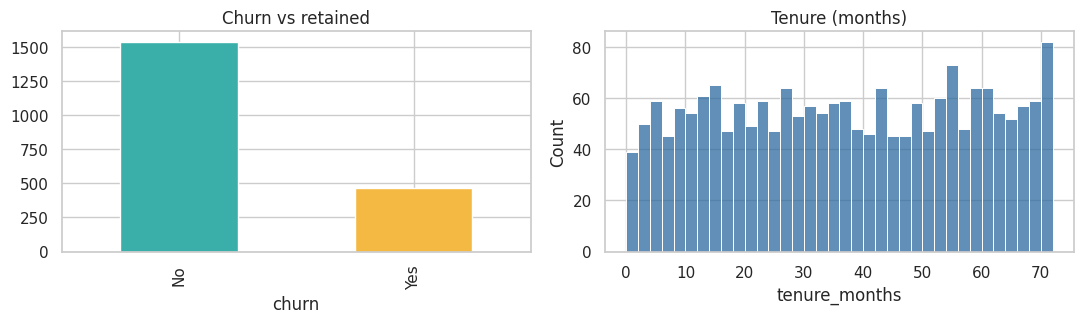

In [ ]:
# --- 4.1 The headline number: how bad is churn? ---
churn_rate = (df['churn'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}  (the minority class)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#3AAFA9', '#F4B942'])
ax[0].set_title('Churn vs retained')
sns.histplot(df['tenure_months'], bins=36, ax=ax[1], color='#2D6A9F')
ax[1].set_title('Tenure (months)')
plt.tight_layout(); plt.show()

In [ ]:
# --- 4.2 Conditional probability: P(churn | contract)  (Bayes/stats, U6) ---
# A contract is the single biggest lever in telecom retention.
by_contract = df.groupby('contract')['churn'].apply(lambda s: (s == 'Yes').mean())
print('P(churn | contract):')
print((by_contract).round(3).sort_values(ascending=False))
print(f'\nBase rate P(churn) = {churn_rate:.3f}')
print('Month-to-month customers churn far above the base rate.')

P(churn | contract):
contract
Month-to-month    0.346
One year          0.157
Two year          0.055
Name: churn, dtype: float64

Base rate P(churn) = 0.232
Month-to-month customers churn far above the base rate.


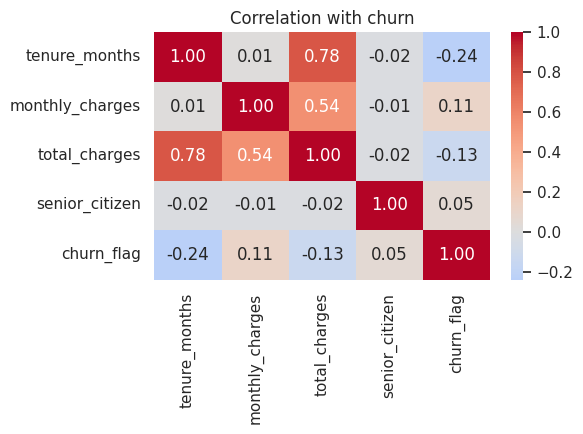

In [ ]:
# --- 4.3 Numeric drivers: correlation heatmap (U9) ---
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)
num = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen', 'churn_flag']
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with churn'); plt.tight_layout(); plt.show()


In [ ]:
# 1. churn rate by payment_method
churn_by_payment = df.groupby('payment_method')['churn'] \
                     .apply(lambda x: (x == 'Yes').mean()) \
                     .sort_values(ascending=False)

print("P(churn | payment_method):")
print(churn_by_payment.round(3))


# 2. mean monthly_charges by churn
mean_charges = df.groupby('churn')['monthly_charges'].mean()

print("\nMean monthly charges:")
print(mean_charges.round(2))


# 3. Do higher charges drive churn?
# Customers who churn generally have higher monthly charges than retained customers.
# This suggests that higher monthly costs may increase the likelihood of churn.

P(churn | payment_method):
payment_method
Electronic check    0.280
Credit card         0.213
Bank transfer       0.207
Mailed check        0.205
Name: churn, dtype: float64

Mean monthly charges:
churn
No     52.62
Yes    58.24
Name: monthly_charges, dtype: float64


In [ ]:
# --- 5.1 Aggregate USAGE (3 months -> per-customer averages) ---
usage_agg = usage.groupby('customer_id').agg(
    avg_minutes=('call_minutes', 'mean'),
    avg_data_gb=('data_gb', 'mean'),
    avg_sms=('sms_count', 'mean'),
    avg_dropped=('dropped_calls', 'mean'),
).reset_index().round(2)

# --- 5.2 Aggregate TICKETS (complaint behaviour) ---
tickets_agg = tickets.groupby('customer_id').agg(
    n_tickets=('issue_type', 'size'),
    n_unresolved=('resolved', lambda s: (s == 'No').sum()),
).reset_index()

# --- 5.3 Join everything onto the customer table ---
feat = df.merge(usage_agg, on='customer_id', how='left') \
         .merge(tickets_agg, on='customer_id', how='left')
feat[['n_tickets', 'n_unresolved']] = feat[['n_tickets', 'n_unresolved']].fillna(0)
print('Feature table:', feat.shape)
feat[['customer_id', 'avg_minutes', 'avg_dropped', 'n_tickets', 'n_unresolved']].head()

Feature table: (2000, 24)


,customer_id,avg_minutes,avg_dropped,n_tickets,n_unresolved
0,TEL00001,565.33,1.67,0.0,0.0
1,TEL00002,674.33,0.00,0.0,0.0
2,TEL00003,623.00,2.33,0.0,0.0
3,TEL00004,671.67,4.33,1.0,0.0
4,TEL00005,530.67,2.33,1.0,0.0


In [ ]:
# --- 5.4 Derive new features (ratios, buckets, flags) ---
# average revenue per month of tenure (guard divide-by-zero for new customers)
feat['charges_per_tenure'] = feat['total_charges'] / feat['tenure_months'].replace(0, np.nan)
feat['charges_per_tenure'] = feat['charges_per_tenure'].fillna(feat['monthly_charges'])
# tenure life-stage buckets (binning)
feat['tenure_group'] = pd.cut(feat['tenure_months'], bins=[-1, 6, 24, 48, 100],
                              labels=['new', 'growing', 'established', 'loyal'])
# domain flags
feat['has_complaints'] = (feat['n_tickets'] > 0).astype(int)
feat['is_new'] = (feat['tenure_months'] <= 6).astype(int)
print(feat[['tenure_months', 'tenure_group', 'charges_per_tenure',
            'has_complaints', 'is_new']].head())

   tenure_months tenure_group  charges_per_tenure  has_complaints  is_new
0             68        loyal               44.63               0       0
1             45  established               51.35               0       0
2             49        loyal               51.00               0       0
3             65        loyal               50.90               1       0
4             42  established               61.20               1       0


In [ ]:
import numpy as np

# 1. data_per_minute (guard zero)
feat['data_per_minute'] = feat['avg_data_gb'] / feat['avg_minutes'].replace(0, np.nan)

# (optional: if you want to fill remaining NaN with 0)
feat['data_per_minute'] = feat['data_per_minute'].fillna(0)


# 2. heavy_user flag (top 25% of avg_data_gb)
threshold = feat['avg_data_gb'].quantile(0.75)
feat['heavy_user'] = (feat['avg_data_gb'] >= threshold).astype(int)


# 3. churn rate by heavy_user
churn_rate = feat.groupby('heavy_user')['churn_flag'].mean()

print(churn_rate)

heavy_user
0    0.223333
1    0.258000
Name: churn_flag, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

target = 'churn_flag'
drop = ['customer_id', 'signup_date', 'churn', 'churn_flag']
X = feat.drop(columns=drop)
y = feat[target]

num_features = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen',
                'avg_minutes', 'avg_data_gb', 'avg_sms', 'avg_dropped',
                'n_tickets', 'n_unresolved', 'charges_per_tenure', 'has_complaints', 'is_new']
cat_features = ['gender', 'partner', 'dependents', 'state', 'contract', 'payment_method',
                'paperless_billing', 'internet_service', 'online_security',
                'tech_support', 'tenure_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('churn rate train/test:', round(y_train.mean(), 3), '/', round(y_test.mean(), 3))

pre = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])  # fit on train only -> no leakage

train: (1500, 26) | test: (500, 26)
churn rate train/test: 0.232 / 0.232


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = Pipeline([
    ('prep', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print('Accuracy :', round((pred == y_test).mean(), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, proba), 3))
print('\nClassification report (class 1 = churn):')
print(classification_report(y_test, pred, digits=3))

Accuracy : 0.7
ROC-AUC  : 0.79

Classification report (class 1 = churn):
              precision    recall  f1-score   support

           0      0.898     0.688     0.779       384
           1      0.417     0.741     0.534       116

    accuracy                          0.700       500
   macro avg      0.658     0.714     0.656       500
weighted avg      0.786     0.700     0.722       500



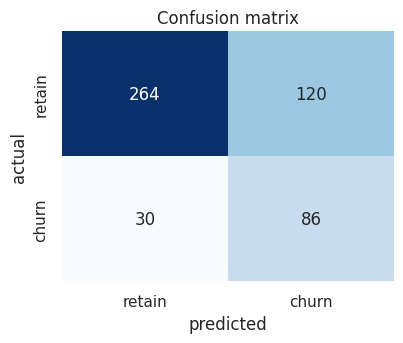

In [ ]:
# Confusion matrix — how many at-risk customers did we catch?
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['retain', 'churn'], yticklabels=['retain', 'churn'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

In [ ]:
# Which features point to churn? (logistic-regression coefficients)
ohe = model.named_steps['prep'].named_transformers_['cat']
names = num_features + list(ohe.get_feature_names_out(cat_features))
coefs = pd.Series(model.named_steps['clf'].coef_[0], index=names)
print('Top 6 churn-INCREASING signals:')
print(coefs.sort_values(ascending=False).head(6).round(2))
print('\nTop 6 churn-REDUCING signals:')
print(coefs.sort_values().head(6).round(2))

Top 6 churn-INCREASING signals:
contract_Month-to-month                1.19
online_security_No internet service    0.79
tech_support_No                        0.27
monthly_charges                        0.24
charges_per_tenure                     0.24
state_Tamil Nadu                       0.23
dtype: float64

Top 6 churn-REDUCING signals:
contract_Two year                  -1.23
online_security_Yes                -0.64
tenure_months                      -0.63
online_security_No                 -0.35
tech_support_No internet service   -0.24
internet_service_No                -0.24
dtype: float64


In [ ]:
segment_risk = df.pivot_table(
    values='churn_flag',
    index='contract',
    columns='internet_service',
    aggfunc='mean'
)

print(segment_risk)

internet_service       DSL  Fiber optic        No
contract                                         
Month-to-month    0.306590     0.412134  0.271967
One year          0.103226     0.220430  0.116279
Two year          0.020942     0.085308  0.057143


In [ ]:
max_risk = segment_risk.stack().idxmax()
max_value = segment_risk.stack().max()

print("Highest-risk segment:", max_risk)
print("Churn rate:", max_value)

Highest-risk segment: ('Month-to-month', 'Fiber optic')
Churn rate: 0.4121338912133891


In [ ]:
feat['tickets_per_year'] = feat['n_tickets'] / (feat['tenure_months'] / 12 + 1)

corr = feat['tickets_per_year'].corr(feat['churn_flag'])
print("Correlation with churn:", corr)

Correlation with churn: 0.18662044519827836


In [ ]:
proba = model.predict_proba(X_test)[:, 1]
y_true = y_test.values
pred_03 = (proba > 0.3).astype(int)
pred_05 = (proba > 0.5).astype(int)

In [ ]:
def confusion_stats(y_true, y_pred):
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    return tp, fp, fn

tp03, fp03, fn03 = confusion_stats(y_true, pred_03)
tp05, fp05, fn05 = confusion_stats(y_true, pred_05)

print("Threshold 0.3 → TP:", tp03, "FP:", fp03, "FN:", fn03)
print("Threshold 0.5 → TP:", tp05, "FP:", fp05, "FN:", fn05)

Threshold 0.3 → TP: 104 FP: 221 FN: 12
Threshold 0.5 → TP: 86 FP: 120 FN: 30
